In [15]:
import math
import torch
from torch import nn
import mlflow
import torchvision
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
import io 
import matplotlib.cm as cm
from datetime import datetime
import torch
import torchvision
import torchvision.transforms as transforms

In [16]:
from model import ViTForClassfication

In [17]:
def prepare_data(batch_size=4, num_workers=2, train_sample_size=None, test_sample_size=None):
    train_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=2),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=train_transform)
    if train_sample_size is not None:
        # Randomly sample a subset of the training set
        indices = torch.randperm(len(trainset))[:train_sample_size]
        trainset = torch.utils.data.Subset(trainset, indices)



    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                            shuffle=True, num_workers=num_workers)

    test_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=test_transform)
    if test_sample_size is not None:
        # Randomly sample a subset of the test set
        indices = torch.randperm(len(testset))[:test_sample_size]
        testset = torch.utils.data.Subset(testset, indices)

    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                            shuffle=False, num_workers=num_workers)

    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    return trainloader, testloader, classes

In [18]:
#@title Utils 🛠️
import json, os, math
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn import functional as F
import torchvision
import torchvision.transforms as transforms


def save_experiment(experiment_name, config, model, train_losses, test_losses, train_diversity_losses, test_diversity_losses, base_dir="experiments"):
    outdir = os.path.join(base_dir, experiment_name)
    os.makedirs(outdir, exist_ok=True)

    # Save the config
    configfile = os.path.join(outdir, 'config.json')
    with open(configfile, 'w') as f:
        json.dump(config, f, sort_keys=True, indent=4)

    # Save the metrics
    jsonfile = os.path.join(outdir, 'metrics.json')
    with open(jsonfile, 'w') as f:
        data = {
            'train_losses': train_losses,
            'test_losses': test_losses,
            'train_diversity_losses': train_diversity_losses,
            'test_diversity_losses': test_diversity_losses
        }
        json.dump(data, f, sort_keys=True, indent=4)

    # Save the model
    save_checkpoint(experiment_name, model, "final", base_dir=base_dir)


def save_checkpoint(experiment_name, model, epoch, base_dir="experiments"):
    outdir = os.path.join(base_dir, experiment_name)
    os.makedirs(outdir, exist_ok=True)
    cpfile = os.path.join(outdir, f'model_{epoch}.pt')
    torch.save(model.state_dict(), cpfile)


def load_experiment(experiment_name, checkpoint_name="model_final.pt", base_dir="experiments"):
    outdir = os.path.join(base_dir, experiment_name)
    # Load the config
    configfile = os.path.join(outdir, 'config.json')
    with open(configfile, 'r') as f:
        config = json.load(f)
    # Load the metrics
    jsonfile = os.path.join(outdir, 'metrics.json')
    with open(jsonfile, 'r') as f:
        data = json.load(f)
    train_losses = data['train_losses']
    test_losses = data['test_losses']
    train_diversity_losses = data['train_diversity_losses']
    test_diversity_losses = data['test_diversity_losses']
    # Load the model
    model = ViTForClassfication(config)
    cpfile = os.path.join(outdir, checkpoint_name)
    model.load_state_dict(torch.load(cpfile))
    return config, model, train_losses, test_losses, train_diversity_losses, test_diversity_losses


def visualize_images():
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True)
    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    # Pick 30 samples randomly
    indices = torch.randperm(len(trainset))[:30]
    images = [np.asarray(trainset[i][0]) for i in indices]
    labels = [trainset[i][1] for i in indices]
    # Visualize the images using matplotlib
    fig = plt.figure(figsize=(10, 10))
    for i in range(30):
        ax = fig.add_subplot(6, 5, i+1, xticks=[], yticks=[])
        ax.imshow(images[i])
        ax.set_title(classes[labels[i]])


@torch.no_grad()
def visualize_attention(model, output=None, device="mps"):
    """
    Visualize the attention maps of the first 4 images.
    """
    model.eval()
    # Load random images
    num_images = 30
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    # Pick 30 samples randomly
    indices = torch.randperm(len(testset))[:num_images]
    raw_images = [np.asarray(testset[i][0]) for i in indices]
    labels = [testset[i][1] for i in indices]
    # Convert the images to tensors
    test_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    images = torch.stack([test_transform(image) for image in raw_images])
    # Move the images to the device
    images = images.to(device)
    model = model.to(device)
    # Get the attention maps from the last block
    logits, attention_maps = model(images, output_attentions=True)
    # Get the predictions
    predictions = torch.argmax(logits, dim=1)
    # Concatenate the attention maps from all blocks
    attention_maps = torch.cat(attention_maps, dim=1)
    # select only the attention maps of the CLS token
    attention_maps = attention_maps[:, :, 0, 1:]
    # Then average the attention maps of the CLS token over all the heads
    attention_maps = attention_maps.mean(dim=1)
    # Reshape the attention maps to a square
    num_patches = attention_maps.size(-1)
    size = int(math.sqrt(num_patches))
    attention_maps = attention_maps.view(-1, size, size)
    # Resize the map to the size of the image
    attention_maps = attention_maps.unsqueeze(1)
    attention_maps = F.interpolate(attention_maps, size=(32, 32), mode='bilinear', align_corners=False)
    attention_maps = attention_maps.squeeze(1)
    # Plot the images and the attention maps
    fig = plt.figure(figsize=(20, 10))
    mask = np.concatenate([np.ones((32, 32)), np.zeros((32, 32))], axis=1)
    for i in range(num_images):
        ax = fig.add_subplot(6, 5, i+1, xticks=[], yticks=[])
        img = np.concatenate((raw_images[i], raw_images[i]), axis=1)
        ax.imshow(img)
        # Mask out the attention map of the left image
        extended_attention_map = np.concatenate((np.zeros((32, 32)), attention_maps[i].cpu()), axis=1)
        extended_attention_map = np.ma.masked_where(mask==1, extended_attention_map)
        ax.imshow(extended_attention_map, alpha=0.5, cmap='jet')
        # Show the ground truth and the prediction
        gt = classes[labels[i]]
        pred = classes[predictions[i]]
        ax.set_title(f"gt: {gt} / pred: {pred}", color=("green" if gt==pred else "red"))
    if output is not None:
        plt.savefig(output)
    plt.show()

In [19]:
def load_images_from_indices(testset, indices, device="mps"):
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    # Pick 30 samples randomly
    raw_images = [np.asarray(testset[i][0]) for i in indices]
    # Convert the images to tensors
    test_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    images = torch.stack([test_transform(image) for image in raw_images])
    # Move the images to the device
    images = images.to(device)
    return images


def visualize_attention(attention_maps, device="mps"):
    to_pil = torchvision.transforms.ToPILImage()
    images = []

    for idx, amap in enumerate(attention_maps):
        rows, cols = amap.shape[1], amap.shape[0]
        
        amap_norm = amap - amap.min()
        amap_norm = amap_norm / (amap_norm.max() + 1e-8)
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
        fig.suptitle(f"Attention Map {idx}", fontsize=14)
        
        for row in range(rows):
            for col in range(cols):
                img_tensor = amap_norm[col, row]
                axes[row, col].imshow(img_tensor.detach().cpu().numpy(), cmap="viridis")
                axes[row, col].axis("off")
                axes[row, col].set_title(f"[{col},{row}]", fontsize=7)
        
        plt.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
        buf.seek(0)
        images.append(Image.open(buf).copy())
        plt.close(fig)

    return images

def visualize_attention_on_images(attention_maps, images, alpha=0.5):
    """
    attention_maps: lista de tensores, cada uno [10, 4, 65, 65]
    images:         Tensor [10, 3, 32, 32]
    """
    patch_grid = int(64 ** 0.5)  # 8
    img_size = images.shape[-1]  # 32
    result_images = []

    imgs_np = (images.cpu().float() * 0.5 + 0.5).clamp(0, 1)
    imgs_np = imgs_np.permute(0, 2, 3, 1).numpy()  # [10, 32, 32, 3]

    for idx, amap in enumerate(attention_maps):
        # Extraer patches: [10, 4, 65, 65] → [:, :, 0, 1:] → [10, 4, 64]
        attn = amap[:, :, 0, 1:]
        n_cols = attn.shape[0]  # 10
        n_rows = attn.shape[1]  # 4 heads

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
        fig.suptitle(f"Attention Map {idx}", fontsize=14)

        for row in range(n_rows):
            for col in range(n_cols):
                a = attn[col, row].cpu().float()
                a = a - a.min()
                a = a / (a.max() + 1e-8)
                a = a.reshape(patch_grid, patch_grid).detach().numpy()
                a_resized = np.array(
                    Image.fromarray((a * 255).astype(np.uint8)).resize(
                        (img_size, img_size), resample=Image.BILINEAR
                    )
                ) / 255.0

                heatmap = cm.viridis(a_resized)[..., :3]
                overlay = (1 - alpha) * imgs_np[col] + alpha * heatmap

                axes[row, col].imshow(overlay.clip(0, 1))
                axes[row, col].axis("off")
                if row == 0:
                    axes[row, col].set_title(f"img {col}", fontsize=7)
                if col == 0:
                    axes[row, col].set_ylabel(f"head {row}", fontsize=7)

        plt.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
        buf.seek(0)
        result_images.append(Image.open(buf).copy())
        plt.close(fig)

    return result_images

In [20]:
config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48, # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10, # num_classes of CIFAR10
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": False,
}

model = ViTForClassfication(config)

random_input = torch.randn(1, 3, 32, 32)
logits, attention_maps = model(random_input, output_attentions=True)
print(len(attention_maps))
print(attention_maps[0].shape)

4
torch.Size([1, 4, 65, 65])


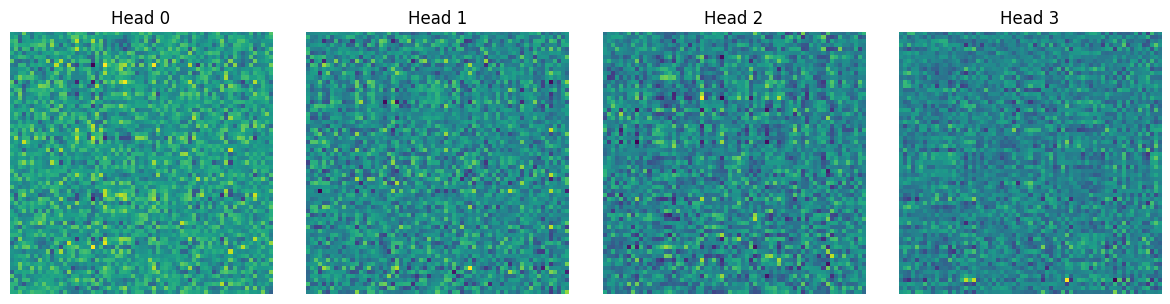

In [21]:
def visualize_matrix(t):
    t = t.squeeze(0)  # [4, 65, 65]
    num_heads = t.shape[0]
    fig, axes = plt.subplots(1, num_heads, figsize=(num_heads * 3, 3))
    for i in range(num_heads):
        axes[i].imshow(t[i].cpu().detach().numpy(), cmap='viridis')
        axes[i].set_title(f'Head {i}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
visualize_matrix(attention_maps[-2])

In [22]:
def diversity_loss(attn):
    """
    attn: (batch, n_heads, n_tokens) — distribuciones de atención ya softmax
    
    Para cada cabeza i, calcula qué tan similar es a cada otra cabeza j
    usando el producto punto (análogo a tr(x·T) del paper).
    
    Luego pasa por softmax para obtener una "distribución de similitud"
    y penaliza cuando alguna cabeza j es muy similar a i.
    
    El loss total es la suma sobre todas las cabezas.
    """
    batch, n_heads, n_tokens = attn.shape
    
    # Producto punto entre todos los pares de cabezas
    # attn: (batch, n_heads, n_tokens)
    # similarity: (batch, n_heads, n_heads)
    similarity = torch.bmm(attn, attn.transpose(1, 2))  # x_i · x_j
    
    # Enmascarar la diagonal (no comparar cabeza consigo misma)
    mask = ~torch.eye(n_heads, dtype=torch.bool).unsqueeze(0)  # (1, n_heads, n_heads)
    
    # Para cada cabeza i, softmax sobre las similitudes con las demás
    # Esto es: exp(x_i · x_j) / sum_k≠i exp(x_i · x_k)
    sim_masked = similarity.masked_fill(~mask, float('-inf'))
    sim_softmax = F.softmax(sim_masked, dim=-1)  # (batch, n_heads, n_heads)
    
    # Si todas las cabezas fueran igualmente (dis)similares,
    # esta distribución sería uniforme → entropía máxima → bien
    # Si una cabeza j domina → entropía baja → mal → hay redundancia
    
    # Entropía de la distribución de similitud para cada cabeza
    # H(sim_i) = -sum_j p_ij * log(p_ij)
    log_sim = sim_softmax.clamp(min=1e-10).log()
    entropy_per_head = -(sim_softmax * log_sim).sum(dim=-1)  # (batch, n_heads)
    
    # Queremos MAXIMIZAR entropía → MINIMIZAR -entropía
    # Loss = -entropía promedio (sobre batch y cabezas)
    loss = -entropy_per_head.mean()
    
    return loss, {
        'similarity_matrix': similarity.mean(dim=0),       # (n_heads, n_heads) promedio
        'sim_softmax': sim_softmax.mean(dim=0),             # distribución de similitud promedio
        'entropy_per_head': entropy_per_head.mean(dim=0),   # entropía promedio por cabeza
        'loss': loss.item(),
    }

In [23]:
diversity_loss(attention_maps[-1][:, :, 0, 1:])

(tensor(-1.0986, grad_fn=<NegBackward0>),
 {'similarity_matrix': tensor([[0.0151, 0.0151, 0.0151, 0.0151],
          [0.0151, 0.0152, 0.0151, 0.0151],
          [0.0151, 0.0151, 0.0152, 0.0152],
          [0.0151, 0.0151, 0.0152, 0.0152]], grad_fn=<MeanBackward1>),
  'sim_softmax': tensor([[0.0000, 0.3333, 0.3333, 0.3333],
          [0.3333, 0.0000, 0.3333, 0.3333],
          [0.3333, 0.3333, 0.0000, 0.3333],
          [0.3333, 0.3333, 0.3333, 0.0000]], grad_fn=<MeanBackward1>),
  'entropy_per_head': tensor([1.0986, 1.0986, 1.0986, 1.0986], grad_fn=<MeanBackward1>),
  'loss': -1.0986123085021973})

In [ ]:
#@title Train ViT 🧠 🏋🏽
#@title String fields

is_interpretable = True #@param {type:"boolean"}
exp_name = f'vit-with-10-epochs{"-interpretable" if is_interpretable else ""}' #@param {type:"string"}
batch_size = 32 #@param {type: "integer"}
epochs = 10 #@param {type: "integer"}
lr = 1e-2  #@param {type: "number"}
save_model_every = 0 #@param {type: "integer"}
lambda_loss = 0.3 #@param {type: "number"}

import torch
from torch import nn, optim

mlflow.set_experiment(exp_name)

indices = [0, 10, 23, 45, 67, 89, 123, 145, 167, 189]

device = "cuda" if torch.cuda.is_available() else "cpu"

config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48, # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10, # num_classes of CIFAR10
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": False,
}
# These are not hard constraints, but are used to prevent misconfigurations
assert config["hidden_size"] % config["num_attention_heads"] == 0
assert config['intermediate_size'] == 4 * config['hidden_size']
assert config['image_size'] % config['patch_size'] == 0


class Trainer:
    """
    The simple trainer.
    """

    def __init__(self, model, optimizer, loss_fn, exp_name, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.exp_name = exp_name
        self.device = device

    def train(self, trainloader, testloader, epochs, save_model_every_n_epochs=0):
        """
        Train the model for the specified number of epochs.
        """
        # Keep track of the losses and accuracies
        list_train_diversity_losses = []
        list_train_losses = []
        list_test_losses = []
        list_test_diversity_losses = []


        with mlflow.start_run(run_name="run-descriptivo"):

            mlflow.log_param("epochs", epochs)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("learning_rate", lr)
            mlflow.log_param("lambda_loss", lambda_loss)

            # Train the model
            for i in range(epochs):
                train_loss, train_diversity_loss = self.train_epoch(trainloader)
                accuracy, test_loss, test_diversity_loss = self.evaluate(testloader)

                list_train_losses.append(train_loss)
                list_train_diversity_losses.append(train_diversity_loss)
                list_test_losses.append(test_loss)
                list_test_diversity_losses.append(test_diversity_loss)

                mlflow.log_metric("train_loss", train_loss, step=i)
                mlflow.log_metric("train_diversity_loss", train_diversity_loss, step=i)

                mlflow.log_metric("test_loss", test_loss, step=i)
                mlflow.log_metric("test_accuracy", accuracy, step=i)
                mlflow.log_metric("test_diversity_loss", test_diversity_loss, step=i)
                
                print(f"Epoch: {i+1}, Train loss: {train_loss:.4f}, Train diversity loss: {train_diversity_loss:.4f}, Test loss: {test_loss:.4f}, Test diversity loss: {test_diversity_loss:.4f}, Accuracy: {accuracy:.4f}")

                images = load_images_from_indices(testloader.dataset, indices, device=device)
                logits, attention_maps = self.model(images, output_attentions=True)
                attention_maps_images = visualize_attention(attention_maps, device=device)
                for idx, img in enumerate(attention_maps_images):
                    mlflow.log_image(img, f"attention_maps_epoch_{i+1}_block_{idx}.png")
                attention_on_images = visualize_attention_on_images(attention_maps, images, alpha=0.5)
                for idx, img in enumerate(attention_on_images):
                    mlflow.log_image(img, f"attention_on_images_epoch_{i+1}_block_{idx}.png")
                
                if save_model_every_n_epochs > 0 and (i+1) % save_model_every_n_epochs == 0 and i+1 != epochs:
                    print('\tSave checkpoint at epoch', i+1)
                    save_checkpoint(self.exp_name, self.model, i+1)
        # Save the experiment
        save_experiment(self.exp_name, config, self.model, list_train_losses, list_test_losses, list_train_diversity_losses, list_test_diversity_losses, base_dir="experiments")

    def train_epoch(self, trainloader):
        """
        Train the model for one epoch.
        """
        self.model.train()
        list_diversity_losses = []
        list_losses = []
        list_total_losses = []

        for batch in trainloader:
            # Move the batch to the device
            batch = [t.to(self.device) for t in batch]
            images, labels = batch
            # Zero the gradients
            self.optimizer.zero_grad()
            # Calculate the loss

            logits, attention_maps = self.model(images, output_attentions=True)
            diversity_loss_value, diversity_loss_info = diversity_loss(attention_maps[-1][:, :, 0, 1:])
            loss_fn = self.loss_fn(logits, labels)

            if is_interpretable:
                # print(f"Loss before the lambda combination: {loss_fn.item():.4f}, Diversity loss: {diversity_loss_value.item():.4f}")
                loss = (1 - lambda_loss) * loss_fn + lambda_loss * diversity_loss_value
                # print(f"Combined loss: {loss.item():.4f}")
            else:
                loss = loss_fn

            # Backpropagate the loss
            loss.backward()
            
            # Update the model's parameters
            self.optimizer.step()
            list_total_losses.append(loss_fn.item() * len(images))
            list_diversity_losses.append(diversity_loss_value.item() * len(images))
        return sum(list_total_losses) / len(trainloader.dataset), sum(list_diversity_losses) / len(trainloader.dataset)

    @torch.no_grad()
    def evaluate(self, testloader):
        self.model.eval()
        total_loss = 0
        total_diversity_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in testloader:
                # Move the batch to the device
                batch = [t.to(self.device) for t in batch]
                images, labels = batch

                # Get predictions
                logits, attention_maps = self.model(images, output_attentions=True)
                diversity_loss_value, diversity_loss_info = diversity_loss(attention_maps[-1][:, :, 0, 1:])

                # Calculate the loss
                loss = self.loss_fn(logits, labels)
                total_loss += loss.item() * len(images)
                total_diversity_loss += diversity_loss_value.item() * len(images)

                # Calculate the accuracy
                predictions = torch.argmax(logits, dim=1)
                correct += torch.sum(predictions == labels).item()
        accuracy = correct / len(testloader.dataset)
        avg_loss = total_loss / len(testloader.dataset)
        avg_diversity_loss = total_diversity_loss / len(testloader.dataset)
        return accuracy, avg_loss, avg_diversity_loss


def main():
    # Training parameters
    save_model_every_n_epochs = save_model_every
    # Load the CIFAR10 dataset
    trainloader, testloader, _ = prepare_data(batch_size=batch_size)
    # Create the model, optimizer, loss function and trainer
    model = ViTForClassfication(config)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    loss_fn = nn.CrossEntropyLoss()
    trainer = Trainer(model, optimizer, loss_fn, exp_name, device=device)
    trainer.train(trainloader, testloader, epochs, save_model_every_n_epochs=save_model_every_n_epochs)

main()


/Users/valefeve/Projects/interpretable-transformers/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch: 1, Train loss: 0.3521, Train diversity loss: -1.0986, Test loss: 1.5665, Test diversity loss: -1.0986, Accuracy: 0.4199
Epoch: 2, Train loss: 0.2219, Train diversity loss: -1.0986, Test loss: 1.5309, Test diversity loss: -1.0986, Accuracy: 0.4380
Epoch: 3, Train loss: 0.1783, Train diversity loss: -1.0986, Test loss: 1.4054, Test diversity loss: -1.0986, Accuracy: 0.4943
Epoch: 4, Train loss: 0.1505, Train diversity loss: -1.0986, Test loss: 1.3841, Test diversity loss: -1.0986, Accuracy: 0.4978
Epoch: 5, Train loss: 0.1332, Train diversity loss: -1.0986, Test loss: 1.3239, Test diversity loss: -1.0986, Accuracy: 0.5149
Epoch: 6, Train loss: 0.1136, Train diversity loss: -1.0986, Test loss: 1.3207, Test diversity loss: -1.0986, Accuracy: 0.5159
Epoch: 7, Train loss: 0.0951, Train diversity loss: -1.0986, Test loss: 1.2865, Test diversity loss: -1.0986, Accuracy: 0.5324
Epoch: 8, Train loss: 0.0807, Train diversity loss: -1.0986, Test loss: 1.2052, Test diversity loss: -1.0986, A

In [25]:
current_date = datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
torch.save(model.state_dict(), f"vit_final_{current_date}.pt")

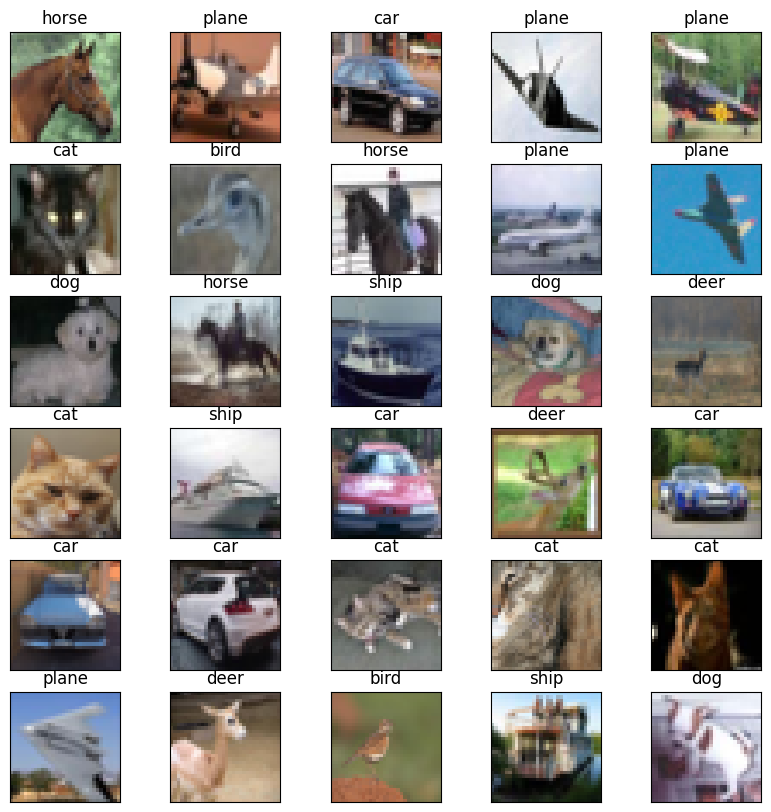

In [26]:
#@title Visualize Dataset
# Show some training images
visualize_images()

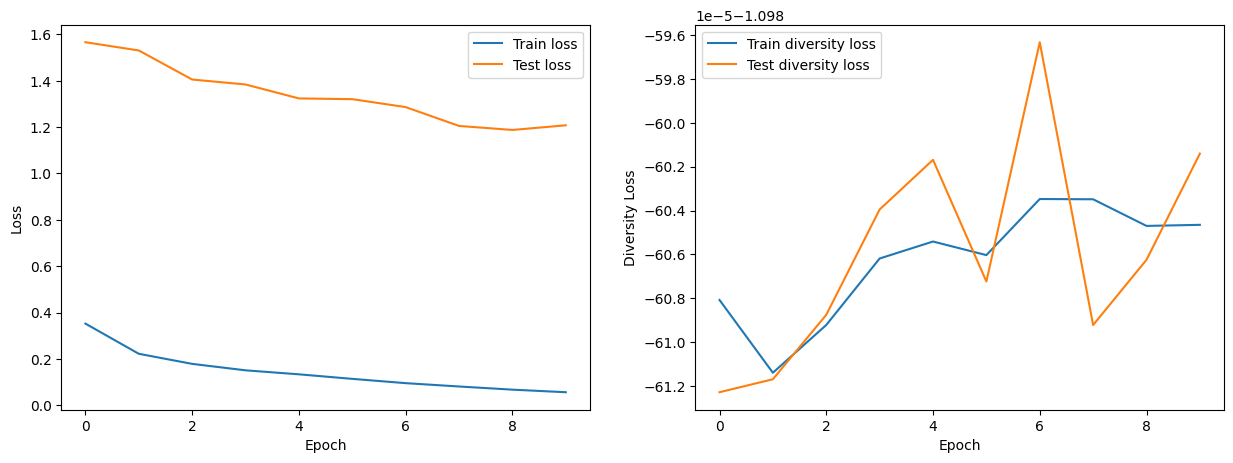

In [27]:
#@title Plot training Results
config, model, train_losses, test_losses, train_diversity_losses, test_diversity_losses = load_experiment(f"{exp_name}/")

import matplotlib.pyplot as plt
# Create two subplots of train/test losses and accuracies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(train_losses, label="Train loss")
ax1.plot(test_losses, label="Test loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax2.plot(train_diversity_losses, label="Train diversity loss")
ax2.plot(test_diversity_losses, label="Test diversity loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Diversity Loss")
ax2.legend()
plt.savefig("metrics.png")
plt.show()

In [14]:
#@title Visualize Attetion
visualize_attention(model, "attention.png")

TypeError: 'ViTForClassfication' object is not iterable